### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [14]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation as sim
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters as pm


In [16]:
pm.show_parameters()
print()
fname = pm.my_name()  # <-- ALTER THIS
print("File with final alpha parameters will be '{}'".format(fname))

Block: 1551055211
Frequency range: 1100 - 1350 MHz
Time range: inf - inf seconds
The cost function denominator will be: radiometer equation (C1).
Masking: None.

File with final alpha parameters will be 'results/vi_nomask_C1_MOD.p'


### 2. Setting up the simulation

We initialize the SatelliteSimulation object, which will store the information.

Getting catalog...
Number of signals in satellite catalog:  21
Getting beam response...
Constellations present:  ['gps-ops' 'glo-ops' 'galileo' 'beidou' 'irnss' 'sbas']
Starting index of satellites:  [ 0  4  9 13 18 20]


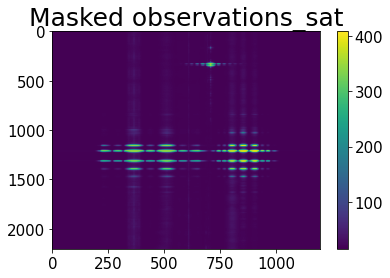

Size of arrays:
 - Frequency:  (1199,)
 - Time:  (2203,)
 - Size of simulated Tb_factors:  (21, 1199)
 - Size of simulated sat_beam:  (6, 1199, 2203)
 - Size of observations:  (1199, 2203)


In [17]:
# initializing the function
path_catalog_old = "Satellite_Catalogue/satellite_constellation_catalog.csv"
sat = sim.SatelliteSimulation(
    block=str(pm.block),
    use_data=True,
    path_data=pm.path_data,
    path_beam=pm.path_data,
    survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency],
    path_catalog=path_catalog_old,  # <-- altered from pm.path_catalog (can't use the new path)
    beam_model=pm.beam_model,
    freq_range=[pm.fs, pm.fe],
    freq_slice=[pm.fs_slice, pm.fe_slice],
    time_slice=[pm.ts_slice, pm.te_slice],
    include_cons=pm.include_cons,
    verbose=True,
)

# applying mask
sat.create_mask(pm.path_nearby, pm.mask_temperature, pm.mask_pix, verbose=True)


In [18]:
# choosing which function to use
if pm.CF_case == "C1":  CF = sim.CF_radiometer
elif pm.CF_case == "C2":  CF = sim.CF_unweighted
    

In [22]:
# defining initial values and boundary conditions
alphas0 = np.zeros(len(sat.catalog))
bnds = [(0.0,None) for _ in range(len(sat.catalog))]

# testing cost function at initial value
alphas0 = np.arange(21)
CF(alphas0,sat)


24230212436.702003

### 3. Running the optimization

We now run the optimization with the functions and parameters defined above.

In [7]:
# running the optimization
print("Running optimization...")
start = time.perf_counter()
signal_PL = opt.minimize(
    fun = CF,
    x0 = alphas0,
    args = (sat,),
    method = "Powell",
    bounds = bnds,
    tol = 1e-6,
    options={"maxiter":20, "disp":True},
)
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


Running optimization...
Optimization terminated successfully.
         Current function value: 346435.353238
         Iterations: 15
         Function evaluations: 5589
This took 19.88 seconds, or 0.33 minutes


In [8]:
# saving best fit values
alphas_best_fit = signal_PL.x
sat.update_alphas(alphas_best_fit)

Catalog updated with alphas!


In [9]:
# saving information in the file
data_info = {
    "initial" : alphas0,
    "time" : [pm.ts_slice, pm.te_slice],
    "frequency_slice" : [pm.fs_slice, pm.fe_slice],
    "best-fit" : alphas_best_fit,
    "chi2_value" : signal_PL.fun,
    "chi2_div" : signal_PL.fun / sat.simulation.size,
}

print(f"Information saved in file '{fname}'.")
pickle.dump( data_info, open(fname,"wb") )

Information saved in file 'results/vi_interval5500-6200_C2.p'.
